# Volatility Forecasting: EWMA vs GARCH

## Research question

**Which model forecasts forward realised S&P 500 volatility most accurately?**

The notebook compares historical volatility, EWMA, GARCH(1,1), EGARCH, GJR-GARCH, and VIX. Forecasts are made out of sample with a rolling estimation window and scored against forward 21-trading-day realised volatility using MSE, MAE, and QLIKE. Install missing dependencies with: pip install yfinance arch plotly ipywidgets.

## Forecasting design

- The target is annualised realised volatility over the next 21 trading days.
- Historical volatility and EWMA update daily using only information available at the forecast date.
- ARCH-family models use a rolling 1,500-day training sample and refit every 21 days; forecasts are held constant between refits.
- VIX is annualised implied volatility for roughly the next 30 days, so it is a market benchmark rather than a horizon-perfect forecast.
- QLIKE is evaluated on variances and penalises poor risk forecasts even when the absolute scale differs.

All model selection is based on the unseen test period, not the in-sample fit.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
import yfinance as yf
from arch import arch_model

START_DATE = '2005-01-01'
END_DATE = pd.Timestamp.today().normalize()
TRADING_DAYS = 252
FORECAST_HORIZON = 21
HISTORICAL_WINDOW = 252
EWMA_LAMBDA = 0.94
ARCH_TRAINING_WINDOW = 1_500
REFIT_EVERY = 21
BACKTEST_DAYS = 750
pd.options.display.float_format = '{:,.5f}'.format

Return observations: 5,438; analysis ends: 2026-08-17


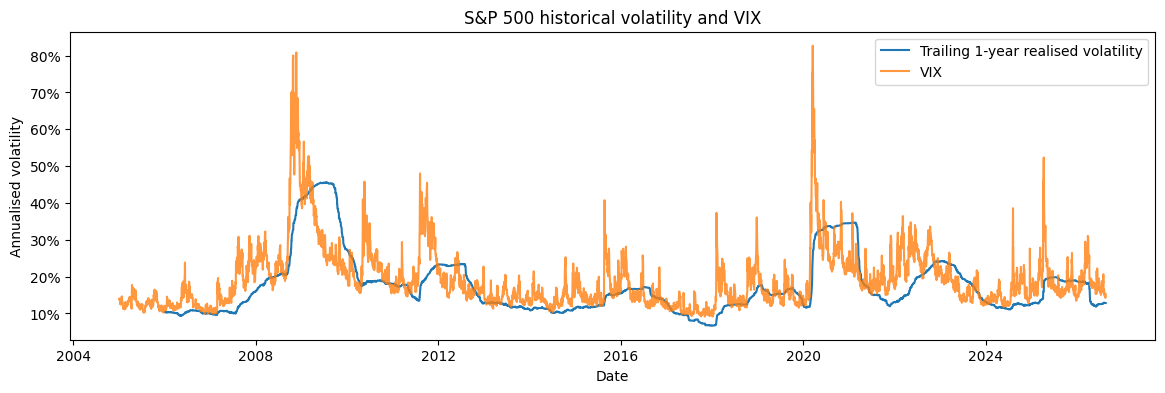

In [3]:
# Use S&P 500 index prices and VIX closing values; adjusted close is robust across yfinance versions.
market = yf.download(['^GSPC', '^VIX'], start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)['Close']
market = market.rename(columns={'^GSPC': 'SPX', '^VIX': 'VIX'}).dropna()
returns = market['SPX'].pct_change().dropna().rename('SPX return')

# At date t this target contains returns t+1 through t+21, preventing any target-period leakage.
forward_realised_vol = returns.rolling(FORECAST_HORIZON).std(ddof=1).shift(-FORECAST_HORIZON) * np.sqrt(TRADING_DAYS)
vix_forecast = (market['VIX'] / 100).reindex(returns.index).rename('VIX')
print(f'Return observations: {len(returns):,}; analysis ends: {returns.index.max().date()}')

fig, axis = plt.subplots(figsize=(14, 4))
axis.plot((returns.rolling(HISTORICAL_WINDOW).std() * np.sqrt(TRADING_DAYS)), label='Trailing 1-year realised volatility')
axis.plot(vix_forecast, alpha=.8, label='VIX')
axis.set(title='S&P 500 historical volatility and VIX', ylabel='Annualised volatility', xlabel='Date')
axis.yaxis.set_major_formatter('{x:.0%}'); axis.legend(); plt.show()

In [4]:
def historical_volatility(returns, window=HISTORICAL_WINDOW):
    return returns.rolling(window).std(ddof=1).shift(1) * np.sqrt(TRADING_DAYS)


def ewma_volatility(returns, decay=EWMA_LAMBDA):
    # The shift means the forecast made on date t excludes the return observed on date t.
    daily_variance = returns.pow(2).ewm(alpha=1 - decay, adjust=False).mean().shift(1)
    return np.sqrt(daily_variance * TRADING_DAYS)


def rolling_arch_volatility(returns, model_name, test_index):
    specifications = {
        'GARCH(1,1)': {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1},
        'EGARCH': {'vol': 'EGARCH', 'p': 1, 'o': 0, 'q': 1},
        'GJR-GARCH': {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1},
    }
    specification = specifications[model_name]
    forecasts = pd.Series(index=test_index, dtype=float, name=model_name)
    for position in range(0, len(test_index), REFIT_EVERY):
        forecast_date = test_index[position]
        location = returns.index.get_loc(forecast_date)
        training = returns.iloc[max(0, location - ARCH_TRAINING_WINDOW):location] * 100
        fitted = arch_model(training, mean='Constant', dist='t', rescale=False, **specification).fit(disp='off')
        variance_path = fitted.forecast(horizon=FORECAST_HORIZON, reindex=False).variance.iloc[-1]
        annualised_vol = np.sqrt(variance_path.mean()) / 100 * np.sqrt(TRADING_DAYS)
        block = test_index[position:position + REFIT_EVERY]
        forecasts.loc[block] = annualised_vol
    return forecasts


test_index = returns.index[-BACKTEST_DAYS:]
forecasts = pd.DataFrame(index=test_index)
forecasts['Historical'] = historical_volatility(returns).reindex(test_index)
forecasts['EWMA'] = ewma_volatility(returns).reindex(test_index)
for model_name in ['GARCH(1,1)', 'EGARCH', 'GJR-GARCH']:
    forecasts[model_name] = rolling_arch_volatility(returns, model_name, test_index)
forecasts['VIX'] = vix_forecast.reindex(test_index)
forecasts['Realised volatility'] = forward_realised_vol.reindex(test_index)
evaluation = forecasts.dropna().copy()
print(f'Comparable out-of-sample forecasts: {len(evaluation):,}')

ValueError: Analytic forecasts not available for horizon > 1

In [ ]:
def forecast_scores(actual, predicted):
    actual_variance, predicted_variance = actual.pow(2), predicted.pow(2).clip(lower=1e-10)
    return pd.Series({
        'MSE': ((predicted - actual) ** 2).mean(),
        'MAE': (predicted - actual).abs().mean(),
        'QLIKE': (np.log(predicted_variance) + actual_variance / predicted_variance).mean(),
        'Bias': (predicted - actual).mean(),
    })


score_table = pd.DataFrame({
    column: forecast_scores(evaluation['Realised volatility'], evaluation[column])
    for column in evaluation.columns if column != 'Realised volatility'
}).T.sort_values('QLIKE')
display(score_table.style.format({'MSE': '{:.6f}', 'MAE': '{:.2%}', 'QLIKE': '{:.4f}', 'Bias': '{:.2%}'}))

fig = go.Figure()
fig.add_trace(go.Scatter(x=evaluation.index, y=evaluation['Realised volatility'], name='Forward realised volatility', line=dict(color='black', width=2)))
for column in evaluation.columns.drop('Realised volatility'):
    fig.add_trace(go.Scatter(x=evaluation.index, y=evaluation[column], name=column))
fig.update_layout(title='Interactive out-of-sample volatility forecasts', xaxis_title='Forecast date', yaxis_title='Annualised volatility', hovermode='x unified')
fig.update_yaxes(tickformat='.0%')
fig.show()

score_plot = score_table.reset_index(names='Model')
go.Figure(go.Bar(x=score_plot.Model, y=score_plot.QLIKE, text=score_plot.QLIKE.round(4), textposition='auto')).update_layout(title='QLIKE ranking: lower is better', yaxis_title='QLIKE').show()

In [ ]:
@interact(model=Dropdown(options=[column for column in evaluation.columns if column != 'Realised volatility'], description='Forecast'))
def forecast_explorer(model):
    plot_data = evaluation[['Realised volatility', model]].tail(252)
    figure = go.Figure()
    for column in plot_data.columns:
        figure.add_trace(go.Scatter(x=plot_data.index, y=plot_data[column], name=column))
    figure.update_layout(title=f'Latest year: {model} versus realised volatility', xaxis_title='Date', yaxis_title='Annualised volatility')
    figure.update_yaxes(tickformat='.0%')
    figure.show()
    display(score_table.loc[[model]])

## Answering the research question

The first row of the QLIKE-ranked table is the preferred realised-volatility forecast for this test. Confirm that the same model is also competitive on MAE and MSE before making a final claim. If VIX outperforms the historical models, interpret that as evidence that option-market information contains useful forward-looking volatility signals, while remembering its approximately 30-day horizon differs from this 21-day target.